<a href="https://colab.research.google.com/github/Falis-EPG/Portal_Colaborador_Fertminas/blob/main/Modelo_de_Previsibilidade_de_Tempo_de_Descarregamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 ML - Previsão de Tempo de Descarregamento
**Objetivo:** Identificar motivos de atrasos e prever o tempo de descarregamento em linhas de produto.

**Modelos testados:** Random Forest · Gradient Boosting · XGBoost

---
## 📌 Instruções
1. Substitua a seção `CARREGAMENTO DE DADOS` pelo seu arquivo real (.xlsx ou .csv)
2. Ajuste os nomes das colunas conforme necessário
3. Execute célula por célula (Ctrl+Enter)

In [1]:
!pip install xgboost shap pandas numpy matplotlib seaborn sklearning --quiet

  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [3]:
np.random.seed(42)
print('✅ Imports concluídos')

✅ Imports concluídos


In [4]:
# ============================================================
# CÉLULA 3 — CARREGAMENTO DE DADOS
# ============================================================
# ▸ OPÇÃO A: Carregar seu arquivo real (descomente uma linha)
# from google.colab import files
# uploaded = files.upload()                          # upload manual
# df = pd.read_excel('seu_arquivo.xlsx')             # ou read_csv
# df = pd.read_csv('seu_arquivo.tsv', sep='\t', decimal=',')

# ▸ OPÇÃO B: Dados sintéticos gerados com base na estrutura real
#   (use enquanto não tiver dados suficientes — mín. recomendado: ~200 linhas)

print('📦 Gerando dataset sintético baseado na estrutura real...')

N = 500   # número de registros sintéticos

fornecedores = ['Melaço de Cana', 'CARAMURU ALIMENTOS', 'BUNGE ALIMENTOS', 'CARGILL', 'ADM DO BRASIL']
descricoes   = ['M2', 'M3', 'M4']
dias_semana  = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado']
observacoes  = [
    '',
    'Não tem Emissão do Ticket Final',
    'Aguardando liberação laboratorial',
    'Problema na bomba de transferência',
    'Falta de operador',
    'Manutenção na linha',
    'Caminhão com problema mecânico',
    'Atraso na chegada do veículo',
]

forn_col     = np.random.choice(fornecedores, N)
desc_col     = np.random.choice(descricoes, N)
dia_col      = np.random.choice(dias_semana, N)
qtd_col      = np.random.uniform(15000, 42000, N)
visc_col     = np.where(np.random.rand(N) < 0.4, np.random.uniform(800, 3000, N), np.nan)
hora_inicio  = np.random.uniform(6, 22, N)   # hora decimal de início (abertura de peso)
atraso_data  = np.random.randint(0, 25, N)   # dias de atraso entre agendamento e recebimento
obs_col      = np.random.choice(observacoes, N, p=[0.55, 0.10, 0.10, 0.08, 0.07, 0.05, 0.03, 0.02])

# ── Tempo operacional (variável alvo) — regras semi-realistas ──────────────
tempo_base = qtd_col / 6000   # base: ~6 ton/h

# Viscosidade alta → mais lento
visc_adj = np.where(~np.isnan(visc_col), (visc_col - 1000) / 1000 * 0.8, 0)

# Início muito cedo ou tarde → penalidade (troca de turno)
hora_adj = np.where((hora_inicio < 7) | (hora_inicio > 21), 1.5, 0)

# Atraso de recebimento → penalidade operacional
atraso_adj = atraso_data * 0.15

# Observações críticas → penalidade
obs_pen = np.where(obs_col != '', np.random.uniform(1, 4, N), 0)

# Fornecedor específico (exemplo: Melaço demora mais por viscosidade)
forn_adj = np.where(forn_col == 'Melaço de Cana', 1.2, 0)

tempo_total = tempo_base + visc_adj + hora_adj + atraso_adj + obs_pen + forn_adj
tempo_total = tempo_total + np.random.normal(0, 0.5, N)   # ruído
tempo_total = np.clip(tempo_total, 0.5, 24)

df = pd.DataFrame({
    'Descricao'        : desc_col,
    'Fornecedor'       : forn_col,
    'Dia_Semana'       : dia_col,
    'Quantidade_kg'    : qtd_col.round(0),
    'Viscosidade'      : visc_col.round(0),
    'Hora_Inicio'      : hora_inicio.round(2),
    'Atraso_Dias'      : atraso_data,
    'Observacao'       : obs_col,
    'Tempo_Operacional': tempo_total.round(2),   # ← VARIÁVEL ALVO (horas)
})

print(f'✅ Dataset gerado: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

📦 Gerando dataset sintético baseado na estrutura real...
✅ Dataset gerado: 500 linhas × 9 colunas


,Descricao,Fornecedor,Dia_Semana,Quantidade_kg,Viscosidade,Hora_Inicio,Atraso_Dias,Observacao,Tempo_Operacional
0,M3,CARGILL,Segunda,25852.0,NaN,10.79,6,,5.30
1,M2,ADM DO BRASIL,Sábado,27957.0,NaN,7.23,14,Falta de operador,8.68
2,M3,BUNGE ALIMENTOS,Quinta,31943.0,NaN,14.01,5,Falta de operador,8.90
3,M2,ADM DO BRASIL,Sexta,38589.0,937.0,18.71,19,,9.30
4,M4,ADM DO BRASIL,Quarta,41570.0,1928.0,17.31,8,Manutenção na linha,11.84
5,M4,CARAMURU ALIMENTOS,Segunda,35743.0,NaN,6.80,21,Atraso na chegada do veículo,13.97
6,M2,BUNGE ALIMENTOS,Sexta,26280.0,1810.0,7.17,19,Problema na bomba de transferência,9.27
7,M2,BUNGE ALIMENTOS,Sábado,26377.0,NaN,12.45,11,Falta de operador,9.50
8,M2,BUNGE ALIMENTOS,Quinta,34915.0,NaN,10.72,18,,8.55
9,M4,ADM DO BRASIL,Sábado,21447.0,NaN,9.72,19,Não tem Emissão do Ticket Final,9.43


ANÁLISE EXPLORATÓRIA

📐 Shape: (500, 9)

🔍 Nulos por coluna:
Descricao              0
Fornecedor             0
Dia_Semana             0
Quantidade_kg          0
Viscosidade          304
Hora_Inicio            0
Atraso_Dias            0
Observacao             0
Tempo_Operacional      0
dtype: int64

📊 Estatísticas - Tempo Operacional (h):
count    500.00
mean       8.49
std        2.38
min        2.39
25%        6.79
50%        8.50
75%        9.97
max       15.99
Name: Tempo_Operacional, dtype: float64


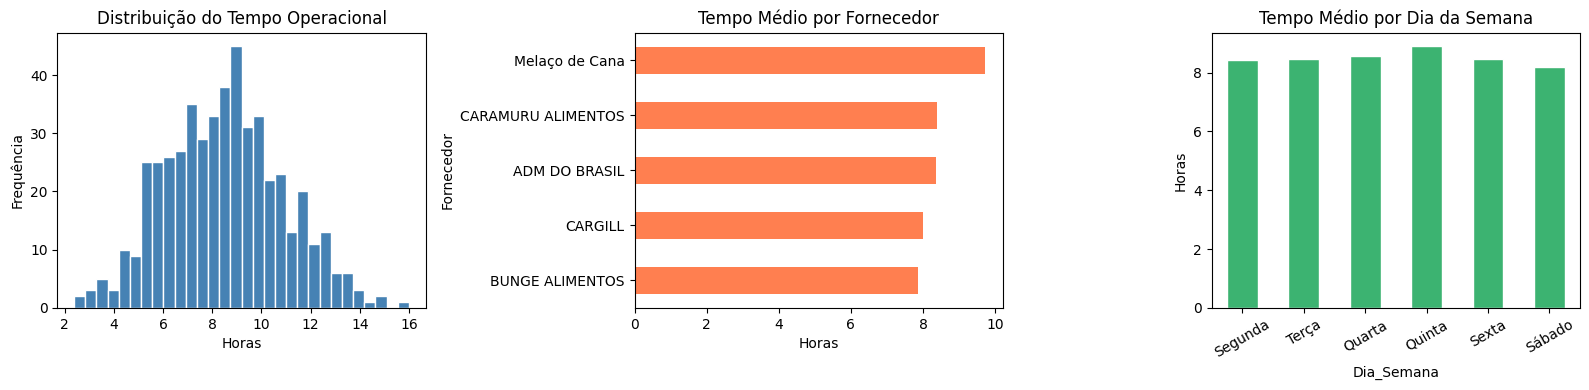

✅ EDA concluída


In [5]:
# ============================================================
# CÉLULA 4 — Análise exploratória (EDA)
# ============================================================
print('='*55)
print('ANÁLISE EXPLORATÓRIA')
print('='*55)
print(f"\n📐 Shape: {df.shape}")
print(f"\n🔍 Nulos por coluna:")
print(df.isnull().sum())
print(f"\n📊 Estatísticas - Tempo Operacional (h):")
print(df['Tempo_Operacional'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma do target
axes[0].hist(df['Tempo_Operacional'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Tempo Operacional')
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Frequência')

# Tempo médio por fornecedor
tempo_forn = df.groupby('Fornecedor')['Tempo_Operacional'].mean().sort_values()
tempo_forn.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Tempo Médio por Fornecedor')
axes[1].set_xlabel('Horas')

# Tempo médio por dia da semana
ordem_dias = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado']
tempo_dia = df.groupby('Dia_Semana')['Tempo_Operacional'].mean().reindex(ordem_dias)
tempo_dia.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Tempo Médio por Dia da Semana')
axes[2].set_ylabel('Horas')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print('✅ EDA concluída')

In [6]:
# ============================================================
# CÉLULA 5 — Pré-processamento
# ============================================================

df_ml = df.copy()

# 1) Flag se há observação crítica
df_ml['Tem_Observacao'] = (df_ml['Observacao'] != '').astype(int)

# 2) Categoria da observação
df_ml['Tipo_Obs'] = df_ml['Observacao'].apply(lambda x:
    'sem_problema' if x == ''
    else 'doc_fiscal'   if 'Ticket' in x or 'Emissão' in x
    else 'laboratorio'  if 'laborat' in x.lower()
    else 'equipamento'  if 'bomba' in x.lower() or 'manut' in x.lower()
    else 'pessoal'      if 'operador' in x.lower()
    else 'veiculo'      if 'Caminhão' in x or 'chegada' in x.lower()
    else 'outro'
)

# 3) Viscosidade: preenche nulos com mediana e cria flag
visc_median = df_ml['Viscosidade'].median()
df_ml['Viscosidade_Flag'] = df_ml['Viscosidade'].isna().astype(int)
df_ml['Viscosidade']      = df_ml['Viscosidade'].fillna(visc_median)

# 4) Faixa de horário de início
df_ml['Faixa_Hora'] = pd.cut(
    df_ml['Hora_Inicio'],
    bins=[0, 7, 12, 17, 22, 24],
    labels=['madrugada','manhã','tarde','noite','meia_noite']
)

# 5) Encoding de variáveis categóricas
cat_cols = ['Descricao', 'Fornecedor', 'Dia_Semana', 'Tipo_Obs', 'Faixa_Hora']
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

# 6) Seleção das features finais
features = [
    'Descricao_enc', 'Fornecedor_enc', 'Dia_Semana_enc',
    'Quantidade_kg', 'Viscosidade', 'Viscosidade_Flag',
    'Hora_Inicio', 'Faixa_Hora_enc',
    'Atraso_Dias',
    'Tem_Observacao', 'Tipo_Obs_enc'
]

TARGET = 'Tempo_Operacional'

X = df_ml[features]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'✅ Features: {len(features)}')
print(f'   Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'\n📋 Features selecionadas:')
for f in features:
    print(f'   • {f}')

✅ Features: 11
   Treino: 400 | Teste: 100

📋 Features selecionadas:
   • Descricao_enc
   • Fornecedor_enc
   • Dia_Semana_enc
   • Quantidade_kg
   • Viscosidade
   • Viscosidade_Flag
   • Hora_Inicio
   • Faixa_Hora_enc
   • Atraso_Dias
   • Tem_Observacao
   • Tipo_Obs_enc


In [16]:
# ============================================================
# CÉLULA 6 — Treinamento dos 3 modelos
# ============================================================

modelos = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=20,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, random_state=42,
        eval_metric='rmse', verbosity=0
    )
}

resultados = []
modelos_treinados = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('🚀 Treinando modelos...\n')

for nome, modelo in modelos.items():
    # Cross-validation
    cv_scores = cross_val_score(modelo, X_train, y_train,
                                cv=kf, scoring='r2')
    # Treino final
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo'         : nome,
        'R² (teste)'     : round(r2, 4),
        'MAE (h)'        : round(mae, 3),
        'RMSE (h)'       : round(rmse, 3),
        'R² CV (média)'  : round(cv_scores.mean(), 4),
        'R² CV (std)'    : round(cv_scores.std(), 4),
    })
    modelos_treinados[nome] = (modelo, y_pred)
    print(f'  ✅ {nome:25s} | R²={r2:.4f} | MAE={mae:.3f}h | RMSE={rmse:.3f}h')

df_res = pd.DataFrame(resultados).sort_values('R² (teste)', ascending=False)
print('\n' + '='*65)
print('TABELA COMPARATIVA DE MODELOS')
print('='*65)
print(df_res.to_string(index=False))

🚀 Treinando modelos...

  ✅ Random Forest             | R²=0.7758 | MAE=0.792h | RMSE=1.018h
  ✅ Gradient Boosting         | R²=0.8255 | MAE=0.742h | RMSE=0.898h
  ✅ XGBoost                   | R²=0.8150 | MAE=0.739h | RMSE=0.925h

TABELA COMPARATIVA DE MODELOS
           Modelo  R² (teste)  MAE (h)  RMSE (h)  R² CV (média)  R² CV (std)
Gradient Boosting      0.8255    0.742     0.898         0.8335       0.0244
          XGBoost      0.8150    0.739     0.925         0.8290       0.0318
    Random Forest      0.7758    0.792     1.018         0.8024       0.0192


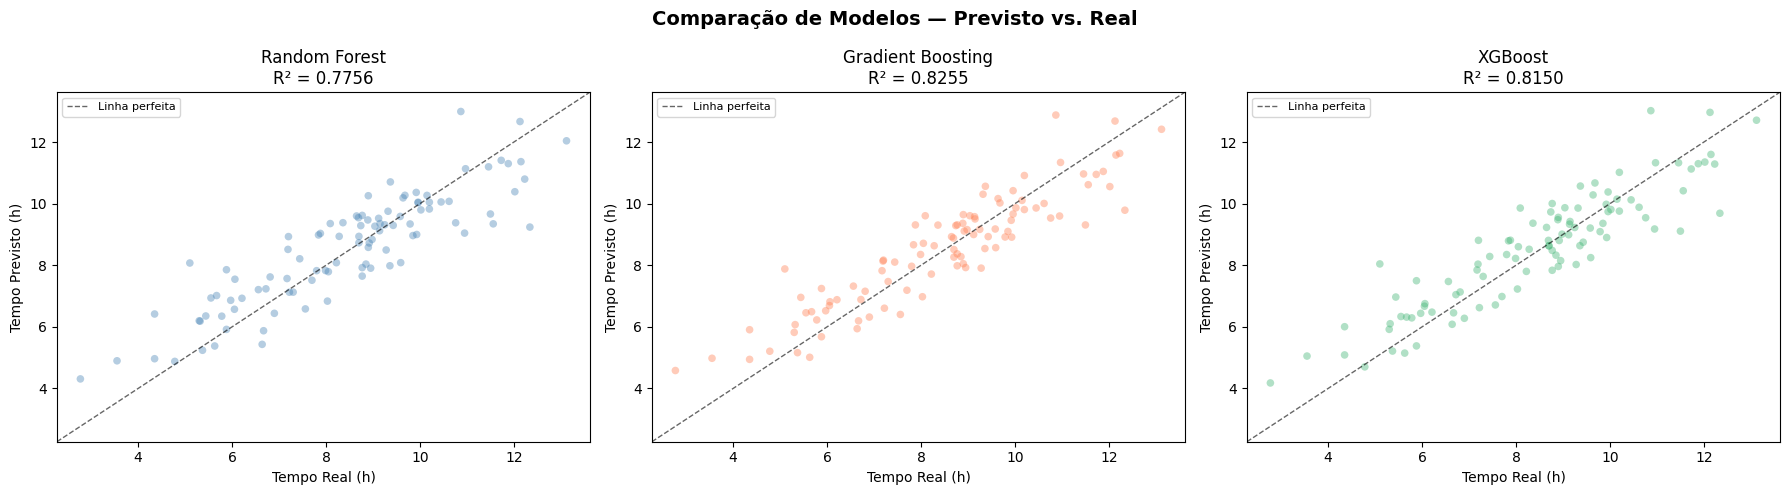

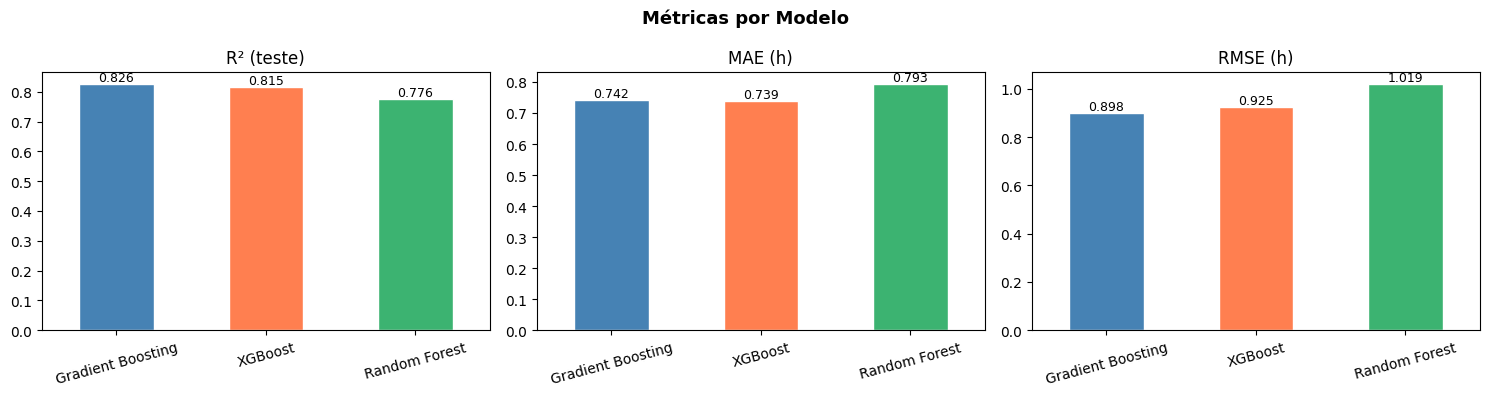

In [8]:
# ============================================================
# CÉLULA 7 — Visualização comparativa
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparação de Modelos — Previsto vs. Real', fontsize=14, fontweight='bold')

cores = ['steelblue', 'coral', 'mediumseagreen']

for ax, (nome, (modelo, y_pred)), cor in zip(axes, modelos_treinados.items(), cores):
    r2 = r2_score(y_test, y_pred)
    ax.scatter(y_test, y_pred, alpha=0.4, color=cor, edgecolors='none', s=30)
    lim = [min(y_test.min(), y_pred.min()) - 0.5,
           max(y_test.max(), y_pred.max()) + 0.5]
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.6, label='Linha perfeita')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Tempo Real (h)')
    ax.set_ylabel('Tempo Previsto (h)')
    ax.set_title(f'{nome}\nR² = {r2:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Gráfico de barras de métricas ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas = ['R² (teste)', 'MAE (h)', 'RMSE (h)']
paleta   = ['steelblue', 'coral', 'mediumseagreen']

for ax, metrica in zip(axes, metricas):
    df_res.plot(x='Modelo', y=metrica, kind='bar', ax=ax,
                color=paleta, legend=False, edgecolor='white')
    ax.set_title(metrica)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Métricas por Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

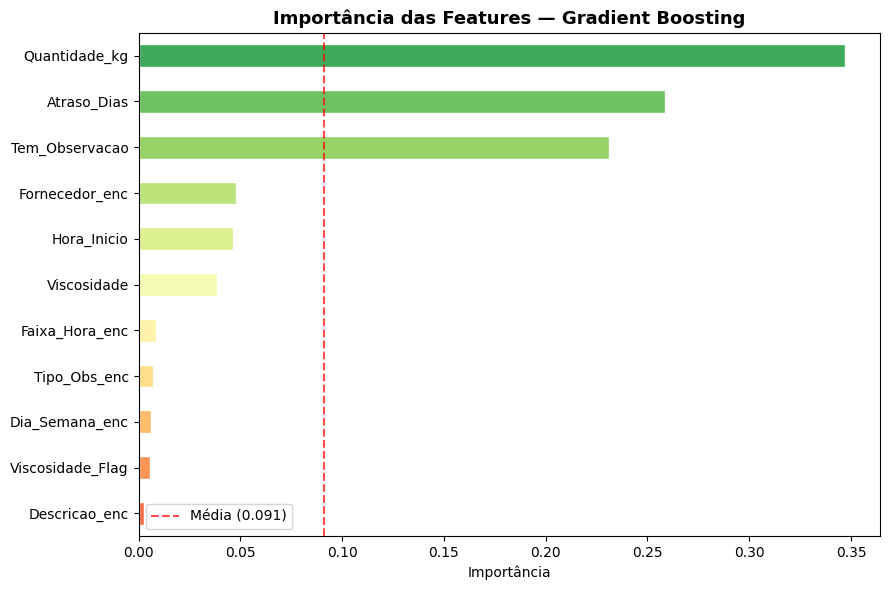


🏆 Melhor modelo: Gradient Boosting

📊 Top 5 fatores mais relevantes para o tempo de descarregamento:
   1. Quantidade_kg             → 0.3469 (34.7%)
   2. Atraso_Dias               → 0.2588 (25.9%)
   3. Tem_Observacao            → 0.2313 (23.1%)
   4. Fornecedor_enc            → 0.0480 (4.8%)
   5. Hora_Inicio               → 0.0461 (4.6%)


In [9]:
# ============================================================
# CÉLULA 8 — Feature Importance (melhor modelo)
# ============================================================

melhor_nome = df_res.iloc[0]['Modelo']
melhor_modelo, _ = modelos_treinados[melhor_nome]

importancias = pd.Series(
    melhor_modelo.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
cores_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(importancias)))
importancias.plot(kind='barh', ax=ax, color=cores_imp, edgecolor='white')
ax.set_title(f'Importância das Features — {melhor_nome}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
ax.axvline(x=importancias.mean(), color='red', linestyle='--',
           alpha=0.7, label=f'Média ({importancias.mean():.3f})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n🏆 Melhor modelo: {melhor_nome}')
print('\n📊 Top 5 fatores mais relevantes para o tempo de descarregamento:')
top5 = importancias.sort_values(ascending=False).head(5)
for i, (feat, val) in enumerate(top5.items(), 1):
    print(f'   {i}. {feat:25s} → {val:.4f} ({val/importancias.sum()*100:.1f}%)')

🔍 Calculando valores SHAP (pode demorar alguns segundos)...


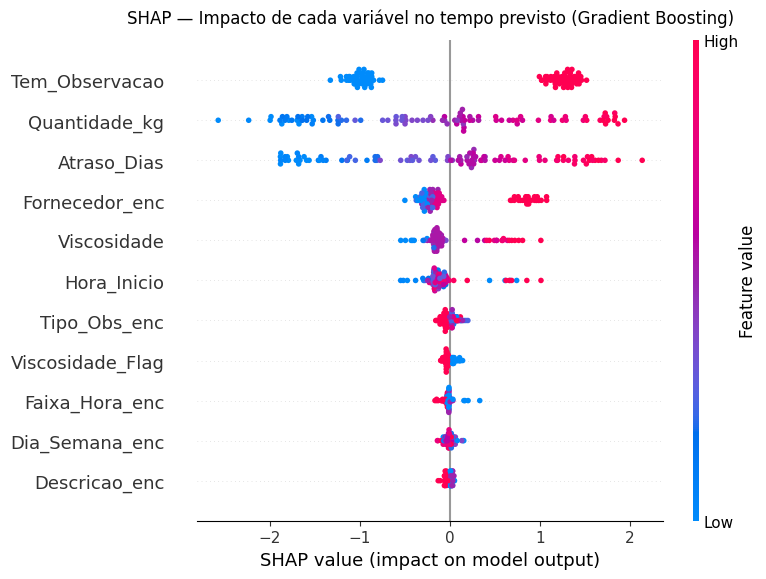


💡 Leitura do gráfico SHAP:
   • Ponto à DIREITA = variável aumenta o tempo de descarregamento
   • Ponto à ESQUERDA = variável reduz o tempo de descarregamento
   • COR VERMELHA = valor alto da feature | AZUL = valor baixo


In [10]:
# ============================================================
# CÉLULA 9 — SHAP: explicabilidade individual
# ============================================================

print('🔍 Calculando valores SHAP (pode demorar alguns segundos)...')

explainer = shap.TreeExplainer(melhor_modelo)
shap_values = explainer.shap_values(X_test)

# Beeswarm plot
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='dot',
                  feature_names=features, show=False, max_display=11)
plt.title(f'SHAP — Impacto de cada variável no tempo previsto ({melhor_nome})',
          fontsize=12, pad=12)
plt.tight_layout()
plt.show()

print('\n💡 Leitura do gráfico SHAP:')
print('   • Ponto à DIREITA = variável aumenta o tempo de descarregamento')
print('   • Ponto à ESQUERDA = variável reduz o tempo de descarregamento')
print('   • COR VERMELHA = valor alto da feature | AZUL = valor baixo')

⏱️  Limiar de atraso: 9.97 h (P75)
   25.0% dos descarregamentos são considerados atrasados



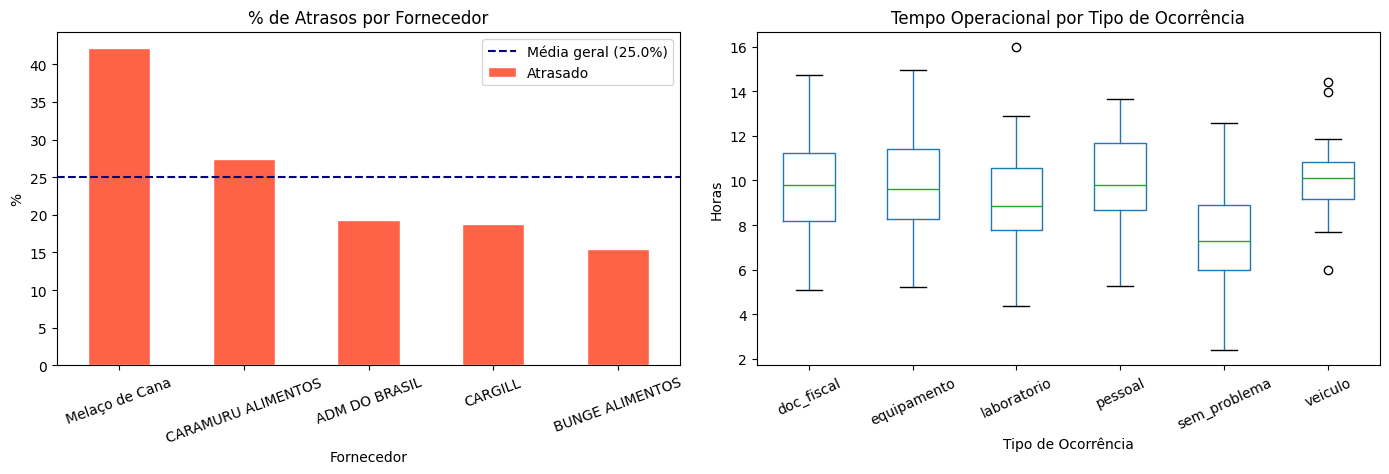

In [11]:
# ============================================================
# CÉLULA 10 — Análise de atrasos
# ============================================================

# Definir atraso como tempo > percentil 75
limiar_atraso = df_ml['Tempo_Operacional'].quantile(0.75)
df_ml['Atrasado'] = (df_ml['Tempo_Operacional'] > limiar_atraso).astype(int)

pct_atraso = df_ml['Atrasado'].mean() * 100
print(f'⏱️  Limiar de atraso: {limiar_atraso:.2f} h (P75)')
print(f'   {pct_atraso:.1f}% dos descarregamentos são considerados atrasados\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# % de atraso por fornecedor
pct_forn = (
    df_ml.groupby('Fornecedor')['Atrasado']
    .mean() * 100
).sort_values(ascending=False)
pct_forn.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].axhline(pct_atraso, color='navy', linestyle='--', label=f'Média geral ({pct_atraso:.1f}%)')
axes[0].set_title('% de Atrasos por Fornecedor')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

# Boxplot: tempo por tipo de observação
df_ml.boxplot(column='Tempo_Operacional', by='Tipo_Obs',
              ax=axes[1], grid=False)
axes[1].set_title('Tempo Operacional por Tipo de Ocorrência')
axes[1].set_xlabel('Tipo de Ocorrência')
axes[1].set_ylabel('Horas')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# CÉLULA 11 — Previsão de novos casos
# ============================================================

print('🔮 SIMULAÇÃO: previsão para novos registros\n')

# ── Monte seus casos aqui ─────────────────────────────────────────────────
novos_casos = pd.DataFrame([
    {
        'Descricao'  : 'M3',
        'Fornecedor' : 'Melaço de Cana',
        'Dia_Semana' : 'Segunda',
        'Quantidade_kg': 35000,
        'Viscosidade': 2200,
        'Hora_Inicio': 8.5,
        'Atraso_Dias': 0,
        'Observacao' : '',
    },
    {
        'Descricao'  : 'M2',
        'Fornecedor' : 'CARAMURU ALIMENTOS',
        'Dia_Semana' : 'Sexta',
        'Quantidade_kg': 30000,
        'Viscosidade': np.nan,
        'Hora_Inicio': 19.0,
        'Atraso_Dias': 15,
        'Observacao' : 'Não tem Emissão do Ticket Final',
    },
])

def preprocessar_novo(df_novo, le_dict, visc_median):
    d = df_novo.copy()
    d['Tem_Observacao']  = (d['Observacao'] != '').astype(int)
    d['Tipo_Obs'] = d['Observacao'].apply(lambda x:
        'sem_problema' if x == ''
        else 'doc_fiscal'   if 'Ticket' in x or 'Emissão' in x
        else 'laboratorio'  if 'laborat' in x.lower()
        else 'equipamento'  if 'bomba' in x.lower() or 'manut' in x.lower()
        else 'pessoal'      if 'operador' in x.lower()
        else 'veiculo'      if 'Caminhão' in x or 'chegada' in x.lower()
        else 'outro'
    )
    d['Viscosidade_Flag'] = d['Viscosidade'].isna().astype(int)
    d['Viscosidade']      = d['Viscosidade'].fillna(visc_median)
    d['Faixa_Hora'] = pd.cut(
        d['Hora_Inicio'],
        bins=[0, 7, 12, 17, 22, 24],
        labels=['madrugada','manhã','tarde','noite','meia_noite']
    )
    for col in ['Descricao', 'Fornecedor', 'Dia_Semana', 'Tipo_Obs', 'Faixa_Hora']:
        le = le_dict[col]
        # Trata categorias desconhecidas mapeando para 0
        d[col + '_enc'] = d[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else 0
        )
    return d[features]

X_novos = preprocessar_novo(novos_casos, le_dict, visc_median)
previsoes = melhor_modelo.predict(X_novos)

print(f'{'Caso':<6} {'Fornecedor':<22} {'Qtd(kg)':<10} {'Atraso':<8} {'Observação':<35} → {'Tempo Previsto':>14}')
print('-' * 100)
for i, (_, row) in enumerate(novos_casos.iterrows()):
    obs = row['Observacao'][:32] + '...' if len(str(row['Observacao'])) > 32 else str(row['Observacao']) or '—'
    print(f'{i+1:<6} {row["Fornecedor"]:<22} {row["Quantidade_kg"]:<10.0f} {row["Atraso_Dias"]:<8} {obs:<35} → {previsoes[i]:>10.2f} h')

print('\n✅ Previsões concluídas!')

🔮 SIMULAÇÃO: previsão para novos registros

Caso   Fornecedor             Qtd(kg)    Atraso   Observação                          → Tempo Previsto
----------------------------------------------------------------------------------------------------
1      Melaço de Cana         35000      0        —                                   →       8.04 h
2      CARAMURU ALIMENTOS     30000      15       Não tem Emissão do Ticket Final     →       9.63 h

✅ Previsões concluídas!


---
## 📋 Próximos passos

| Etapa | Ação |
|---|---|
| 📥 **Dados reais** | Substitua o dataset sintético pelo seu arquivo real na Célula 3 |
| 🔧 **Mais features** | Adicione: temperatura ambiente, operador responsável, tipo de caminhão, número de mangotes |
| 🎯 **Ajuste de hiperparâmetros** | Use `GridSearchCV` ou `Optuna` para otimizar os parâmetros dos modelos |
| 🏷️ **Classificação** | Transforme o target em classes (normal / lento / crítico) e use classificadores |
| 💾 **Exportar modelo** | `import joblib; joblib.dump(melhor_modelo, 'modelo_descarregamento.pkl')` |
| 📊 **Dashboard** | Integre as previsões a um dashboard (Streamlit, Looker Studio, Power BI) |
